In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import csv
import seaborn as sns
import scipy
from scipy import stats
import os
import pickle

In [3]:
data_labels = []
path='/Users/barber.527/Documents/Rojas_Lab/data'
num_rep=4 # this is the number of repeats of each condition.
expt_id = '/260306_IPTG_lytE_cwlO' # the experiment title

In [4]:
temp_path = './outputs'+expt_id+expt_id+'_growth_rate_df.pkl'
with open(temp_path, 'rb') as input:
    df_gr=pickle.load(input)
temp_path = './outputs'+expt_id+expt_id+'_sat_OD_df.pkl'
with open(temp_path, 'rb') as input:
    df_OD=pickle.load(input)
    
to_plot=[]
with open(path+expt_id+expt_id+'_curated.csv') as csv_file:
    csv_reader = csv.reader(csv_file, delimiter=',')
    line_count = 0
    for temp_row in csv_reader:
        to_plot.append(temp_row[0])
        line_count += 1
celltypes=[['Blank','bFB291','bFB292', 'bFB295'], ['', r'$\Delta ponA-P_{spac}ponA$',r'$\Delta ponA-P_{spac}ponA$ $\Delta lytE$', r'$\Delta ponA-P_{spac}ponA$ $\Delta cwlO$']]

In [5]:
df=df_gr.copy()
df['Maximum OD'] = df_OD['Max. density']
temp=[]
for i0 in range(len(df)):
    if df['Condition'].iloc[i0]=='Blank':
        temp.append(i0)
df=df.reset_index(drop=True)
df=df.drop(temp)
df.head(10)
df=df.reset_index(drop=True)
temp1, temp2 = [], []        
for i0 in range(len(df)):    
    ind=np.nonzero([it in df['Condition'].iloc[i0] for it in celltypes[0]])[0][0]
    temp1.append(celltypes[1][ind])
    temp2.append(df['Condition'].iloc[i0][len(celltypes[0][ind])+1:])
df['Celltype'] = temp1
df['Growth condition'] = temp2

Changing the order of things

In [13]:
temp=df['Growth condition'].unique()
sel_conds=[0,2,1,3]
temp_ord=[temp[ind] for ind in sel_conds]
temp_hue = [celltypes[1][1], celltypes[1][2]]

/var/folders/7d/cgvlmd010jb53nbnkbjsc8r80000gp/T/ipykernel_96536/1252262915.py:5: UserWarning: 
The palette list has fewer values (3) than needed (4) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(data=df,x='Growth condition',y='Maximum OD',hue='Celltype', order=temp_ord, hue_order=celltypes[1],capsize=0.15,palette=[colors[1],colors[0],colors[2]])


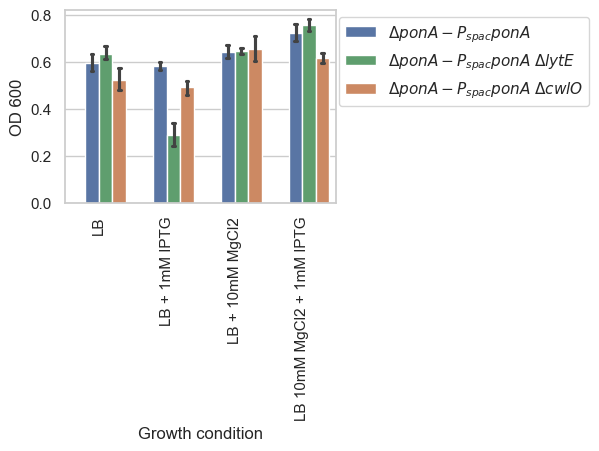

In [14]:
fig=plt.figure(figsize=[3.5,2.5])
sns.set(font_scale=1.0)
sns.set_style('whitegrid')
colors=sns.color_palette()
sns.barplot(data=df,x='Growth condition',y='Maximum OD',hue='Celltype', order=temp_ord, hue_order=celltypes[1],capsize=0.15,palette=[colors[1],colors[0],colors[2]])
plt.ylabel('OD 600')
# plt.xlabel(r'Tunicamycin concentration ($\mu g/mL$)')
xtick_locs,vals=plt.xticks()
plt.xticks(rotation = 90)
plt.legend(loc=[1.01,0.5])
fig.savefig('./outputs'+expt_id+expt_id+'_OD_plot_paper.pdf',bbox_inches='tight')